# Impresso v2 — embedding feasibility

Two independent studies on the v2 aggregated metadata (`tmp/115-...__AGGREGATED.jsonl`, 30 GB), restricted to `tp ∈ {article, ad}` (~64 M items).

**Research 1 — How big is the cohort?**  Count `article`, `ad`, and `article+ad` over a 4×4 sweep of OCRQA × min char-length filters.

**Research 2 — How big / how fast is the Solr index?**  For one canonical cohort, estimate index size and end-to-end query latency in a Solr 9.x deployment, sweeping the **Matryoshka-native** dimensions (`768, 512, 256, 128` — all free truncations of the `gte-multilingual-base` CLS vector) × **Solr-deployable precisions** (`fp32` = `vectorEncoding=FLOAT32`, `int8` = `vectorEncoding=BYTE`).

Numbers are formula-derived (Lucene 9.9 HNSW: `1.1 × (bytes_per_dim × d + 8 × M)` per vector, default `M=16`) for memory, and benchmark-anchored (Burgmans Solr 9.7 / 2.6 M / 768d → ~10 ms HNSW p50, scaled by `log(N)` and per-hop distance cost) for latency. Force-merge, narrow post-filters, and the 1-bit BBQ format (Lucene/Elasticsearch-only today) are discussed in **Research 3** alongside published QPS / recall benchmarks.

`fp16` / `bf16` are not in the sweep — Solr's `vectorEncoding` accepts only `FLOAT32` or `BYTE`, so intermediate float widths cannot be ingested. The Solr-10 `BinaryQuantizedDenseVectorField` is also out of scope until it ships.

Backed by `tmp/aggregated_summary_artad.parquet` (a small pre-bucketed summary built by `tmp/aggregate_artad.py`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'axes.titleweight': 'semibold',
    'axes.titlesize': 11,
})

ARTAD = Path('aggregated_summary_artad.parquet')
FIGURES_DIR = Path('figures'); FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Research 1 — cohort sweep axes
OCRQA_THRESHOLDS = [0.5, 0.6, 0.7, 0.8]
LEN_THRESHOLDS   = [200, 400, 600, 800]

# Research 2 — Solr index estimator axes
# Matryoshka native truncations on gte-multilingual-base ("Elastic Dense Embedding", any d in [128, 768])
DIMS = [768, 512, 256, 128]
# Solr 9.x vectorEncoding accepts only FLOAT32 or BYTE; BBQ (1-bit) is Lucene/Elasticsearch-only today.
BYTES_PER_DIM = {'fp32': 4, 'int8': 1}

# Lucene HNSW per-vector RAM:  ~1.1 × (bytes_per_dim × d + 8 × M)  (vectors + graph edges + codec overhead)
# Sources: Lucene 9.9 Lucene99HnswVectorsFormat javadoc, Lantern HNSW calculator blog.
HNSW_M = 16            # Solr/Lucene default
HNSW_OVERHEAD = 1.1    # +10 % for graph layers + codec metadata

# Latency calibration anchor — Burgmans (Solr 9.7, default config): 2.6 M × 768d × fp32 → ~10 ms HNSW p50.
# Hop count scales ~log(N); per-hop distance cost scales ~linearly with bytes_per_dim × d.
LAT_ANCHOR_N, LAT_ANCHOR_LAT_MS = 2.6e6, 10.0

# Query-encoder forward pass on CPU for a 768d sentence-transformer (sentence-transformers / Burgmans / Sease).
ENCODER_FWD_MS = (10, 40)

# Canonical cohort for Research 2 (single point in the Research-1 sweep)
CANON_OCRQA = 0.6
CANON_LEN   = 400


def human_bytes(n: float) -> str:
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if n < 1024:
            return f'{n:.2f} {unit}'
        n /= 1024
    return f'{n:.2f} PB'


def fmt_lat(s: float) -> str:
    if s < 1e-3: return f'{s*1e6:.1f} µs'
    if s < 1:    return f'{s*1e3:.1f} ms'
    return f'{s:.2f} s'

In [2]:
artad = pd.read_parquet(ARTAD)
artad_total = int(artad['n'].sum())
print(f'rows in summary : {len(artad):,}')
print(f'article+ad items: {artad_total:,}')
print(artad.groupby('tp')['n'].sum().to_string())

rows in summary : 5,155
article+ad items: 63,992,201
tp
ad         18516758
article    45475443


In [3]:
# Cumulative drop ladder — quantify what's filtered out before the Research-1 sweep starts.
# 'NA', '<0.5', '<200' buckets are emitted by aggregate_artad.py and present in the parquet;
# the count_for() helper defined below silently drops these three categories.
_total   = int(artad['n'].sum())
_n_NA    = int(artad.loc[artad['ocrqa_bucket'] == 'NA',    'n'].sum())
_n_lt05  = int(artad.loc[artad['ocrqa_bucket'] == '<0.5',  'n'].sum())
# After dropping NA and <0.5: rows with ocrqa in {0.5-0.6, 0.6-0.7, 0.7-0.8, >=0.8}
_post    = artad[artad['ocrqa_bucket'].isin(['0.5-0.6', '0.6-0.7', '0.7-0.8', '>=0.8'])]
_n_lt200 = int(_post.loc[_post['len_bucket'] == '<200', 'n'].sum())
# Canonical cohort: ocrqa >= 0.6 AND len >= 400
_canon   = int(artad[
    artad['ocrqa_bucket'].isin(['0.6-0.7', '0.7-0.8', '>=0.8'])
    & artad['len_bucket'].isin(['400-600', '600-800', '>=800'])
]['n'].sum())

print(f'raw article+ad rows in parquet      : {_total:>12,}')
print(f'  drop NA-OCRQA                     : {-_n_NA:>12,}  ({_n_NA/_total:6.1%})')
print(f'  drop <0.5 OCRQA                   : {-_n_lt05:>12,}  ({_n_lt05/_total:6.1%})')
print(f'  drop <200 chars (post-OCRQA≥0.5)  : {-_n_lt200:>12,}  ({_n_lt200/_total:6.1%})')
print(f'canonical cohort (≥{CANON_OCRQA}, ≥{CANON_LEN})        : {_canon:>12,}  ({_canon/_total:6.1%} of raw)')

raw article+ad rows in parquet      :   63,992,201
  drop NA-OCRQA                     :   -9,117,775  ( 14.2%)
  drop <0.5 OCRQA                   :     -732,258  (  1.1%)
  drop <200 chars (post-OCRQA≥0.5)  :   -5,768,065  (  9.0%)
canonical cohort (≥0.6, ≥400)        :   38,689,459  ( 60.5% of raw)


## Research 1 — cohort sizes

Cumulative thresholds from the pre-bucketed summary. `NA` ocrqa rows are excluded throughout (no quality signal → not search-worthy).

In [4]:
OCRQA_GEQ = {
    0.5: ['0.5-0.6', '0.6-0.7', '0.7-0.8', '>=0.8'],
    0.6: ['0.6-0.7', '0.7-0.8', '>=0.8'],
    0.7: ['0.7-0.8', '>=0.8'],
    0.8: ['>=0.8'],
}
LEN_GEQ = {
    200: ['200-400', '400-600', '600-800', '>=800'],
    400: ['400-600', '600-800', '>=800'],
    600: ['600-800', '>=800'],
    800: ['>=800'],
}


def count_for(ocrqa_t: float, len_t: int, tp: str | None = None, df: pd.DataFrame = None) -> int:
    d = artad if df is None else df
    sub = d[d['ocrqa_bucket'].isin(OCRQA_GEQ[ocrqa_t])
            & d['len_bucket'].isin(LEN_GEQ[len_t])]
    if tp is not None:
        sub = sub[sub['tp'] == tp]
    return int(sub['n'].sum())


def grid(tp: str | None = None) -> pd.DataFrame:
    return pd.DataFrame(
        {f'len ≥ {lt}': [count_for(qt, lt, tp=tp) for qt in OCRQA_THRESHOLDS] for lt in LEN_THRESHOLDS},
        index=[f'ocrqa ≥ {qt}' for qt in OCRQA_THRESHOLDS],
    )

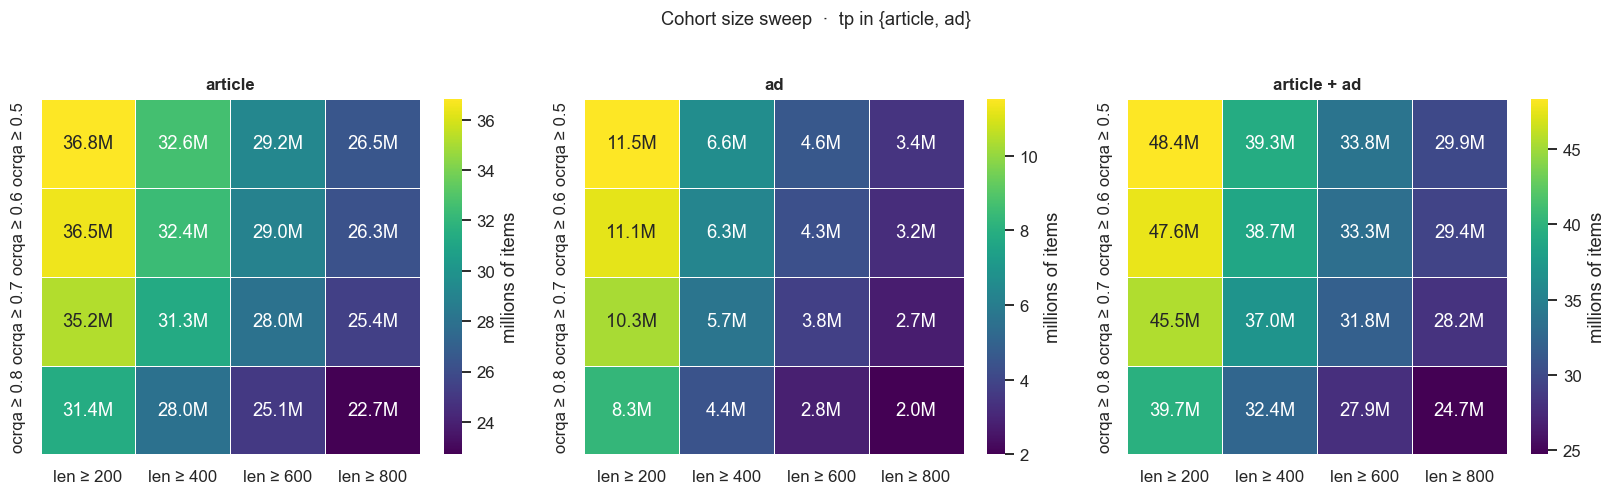

,len ≥ 200,len ≥ 400,len ≥ 600,len ≥ 800
ocrqa ≥ 0.5,48374103,39279446,33791140,29884189
ocrqa ≥ 0.6,47633501,38689459,33289127,29440729
ocrqa ≥ 0.7,45532163,36998573,31839690,28153745
ocrqa ≥ 0.8,39710075,32377659,27911409,24700317


In [5]:
g_article = grid('article')
g_ad      = grid('ad')
g_both    = grid()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, g, title in zip(axes, [g_article, g_ad, g_both], ['article', 'ad', 'article + ad']):
    annot = (g / 1e6).map(lambda x: f'{x:.1f}M')
    sns.heatmap(g / 1e6, annot=annot.values, fmt='', cmap='viridis',
                cbar_kws={'label': 'millions of items'}, linewidths=0.4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Cohort size sweep  ·  tp in {article, ad}', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cohort_sweep.png', bbox_inches='tight')
plt.show()

g_both

## Research 2 — Solr index size and HNSW latency estimator

For the canonical cohort `(ocrqa ≥ 0.6, len ≥ 400, tp ∈ {article, ad})`, sweep the embedding format Solr will actually run:

- **Index size** = `N × 1.1 × (bytes_per_dim × d + 8 × M)` (Lucene HNSW formula, default `M = 16`).
- **HNSW p50 latency** = anchored at Burgmans 2.6 M × 768d × fp32 ≈ 10 ms, scaled by `log(N)/log(2.6 M)` (hop count) × `(bytes_per_dim × d) / (4 × 768)` (per-hop distance cost).
- **End-to-end p50** = HNSW + a 10–40 ms CPU encoder forward pass.

Change `CANON_OCRQA` / `CANON_LEN` in cell 2 to re-target.

> **`gte-multilingual-base` is Matryoshka-trained** ("Elastic Dense Embedding" in the Alibaba model card). Any `d ∈ [128, 768]` is a free truncation of the CLS vector — `embeddings = outputs.last_hidden_state[:, 0][:dimension]`. **No PCA**, no calibration set, no separate query-time projection. The MTEB English ablation in the model card shows performance is approximately flat down to 512d and degrades gracefully below; recall impact at 256d / 128d should be measured on the Impresso eval set, but the option is **first-class on this model**.

> **Estimator scope.** Memory numbers are formula-derived (Lucene 9.9 `Lucene99HnswVectorsFormat`); latency numbers are extrapolations from one published Solr benchmark (Burgmans 2.6 M default config) and assume `efSearch ≈ 100`, no force-merge, single-segment-traversal-cost-equivalent. They are **planning numbers, not SLOs** — replace with measured QPS once a real index lands. The `binary` (BBQ, 1-bit) row is intentionally absent because Solr 9.x cannot ingest it; it is discussed in Research 3.

In [6]:
N = count_for(CANON_OCRQA, CANON_LEN)
print(f'cohort N (ocrqa ≥ {CANON_OCRQA}, len ≥ {CANON_LEN}): {N:,} items')


def hnsw_bytes_per_vec(d: int, precision: str) -> float:
    """Lucene 9.9 HNSW: vectors + graph edges + ~10% codec overhead."""
    return HNSW_OVERHEAD * (BYTES_PER_DIM[precision] * d + 8 * HNSW_M)


def index_size_gb(n: int, d: int, precision: str) -> float:
    return n * hnsw_bytes_per_vec(d, precision) / 1e9


def est_hnsw_ms(n: int, d: int, precision: str) -> float:
    """HNSW p50 ≈ anchor × log(N)/log(N_anchor) × (bytes_per_dim·d) / (bytes_anchor·d_anchor)."""
    log_scale  = np.log(n) / np.log(LAT_ANCHOR_N)
    cost_ratio = (BYTES_PER_DIM[precision] * d) / (4 * 768)   # vs Burgmans fp32/768d anchor
    return LAT_ANCHOR_LAT_MS * log_scale * cost_ratio


rows = []
for d in DIMS:
    for prec in BYTES_PER_DIM:
        size_gb = index_size_gb(N, d, prec)
        hnsw_ms = est_hnsw_ms(N, d, prec)
        e2e_lo  = hnsw_ms + ENCODER_FWD_MS[0]
        e2e_hi  = hnsw_ms + ENCODER_FWD_MS[1]
        rows.append({
            'dim': d, 'precision': prec,
            'index_size_GB': size_gb,
            'hnsw_p50_ms':   hnsw_ms,
            'e2e_p50_ms':    e2e_lo,    # encoder lower-bound
            'e2e_p99_ms':    e2e_hi,    # encoder upper-bound stacked on HNSW p50
        })
estimator = pd.DataFrame(rows).set_index(['dim', 'precision'])

display = estimator.copy()
display['index_size_GB'] = display['index_size_GB'].map(lambda v: f'{v:>6.1f} GB')
display['hnsw_p50_ms']   = display['hnsw_p50_ms'].map(lambda v: f'{v:>5.1f} ms')
display['e2e_p50_ms']    = display.apply(lambda r: f'{r.e2e_p50_ms:>5.1f}–{r.e2e_p99_ms:>5.1f} ms', axis=1)
display = display.drop(columns=['e2e_p99_ms']).rename(columns={
    'index_size_GB': 'index size (formula)',
    'hnsw_p50_ms':   'HNSW p50 (calibrated)',
    'e2e_p50_ms':    'end-to-end (+enc 10–40 ms)',
})

print(f'\nSolr index estimator  ·  N = {N/1e6:.1f} M items  ·  M = {HNSW_M}, efSearch ≈ 100, no force-merge')
print(display.to_string())

cohort N (ocrqa ≥ 0.6, len ≥ 400): 38,689,459 items

Solr index estimator  ·  N = 38.7 M items  ·  M = 16, efSearch ≈ 100, no force-merge
              index size (formula) HNSW p50 (calibrated) end-to-end (+enc 10–40 ms)
dim precision                                                                      
768 fp32                  136.2 GB               11.8 ms              21.8– 51.8 ms
    int8                   38.1 GB                3.0 ms              13.0– 43.0 ms
512 fp32                   92.6 GB                7.9 ms              17.9– 47.9 ms
    int8                   27.2 GB                2.0 ms              12.0– 42.0 ms
256 fp32                   49.0 GB                3.9 ms              13.9– 43.9 ms
    int8                   16.3 GB                1.0 ms              11.0– 41.0 ms
128 fp32                   27.2 GB                2.0 ms              12.0– 42.0 ms
    int8                   10.9 GB                0.5 ms              10.5– 40.5 ms


/var/folders/4m/l5rkp4s94jg_fr07xhlzksb00000gs/T/ipykernel_20653/51405787.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


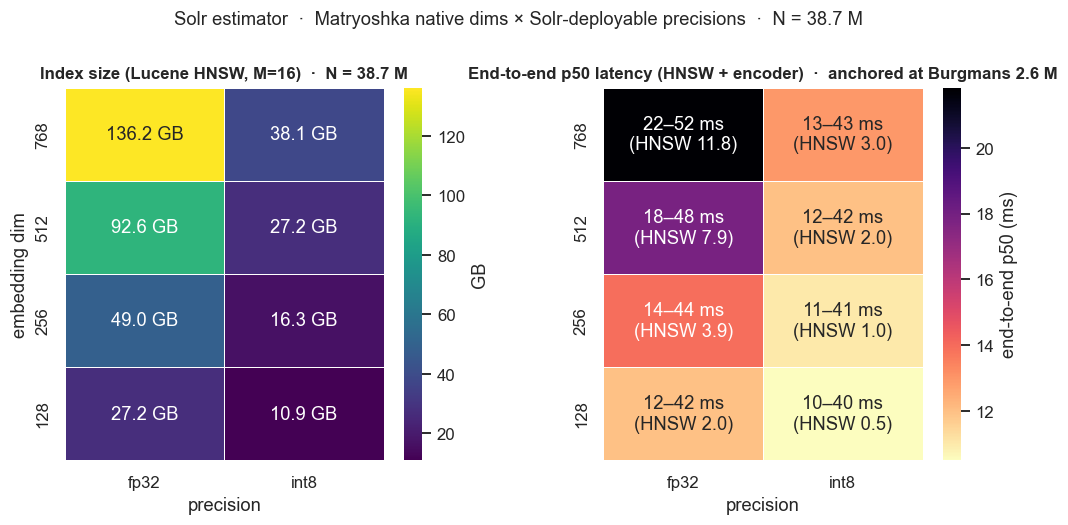

In [7]:
# Render the estimator as two side-by-side heatmaps sharing axes (rows = dim, cols = precision):
#   left  = index size in GB (Lucene HNSW formula — exact for given M)
#   right = end-to-end p50 in ms (HNSW + encoder fwd-pass; calibrated extrapolation)
size_pivot = estimator['index_size_GB'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))
e2e_lo     = estimator['e2e_p50_ms'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))
e2e_hi     = estimator['e2e_p99_ms'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))
hnsw_only  = estimator['hnsw_p50_ms'].unstack('precision').reindex(index=DIMS, columns=list(BYTES_PER_DIM))

size_annot = size_pivot.map(lambda v: f'{v:.1f} GB')
e2e_annot  = pd.DataFrame(
    [[f'{lo:.0f}–{hi:.0f} ms\n(HNSW {h:.1f})' for lo, hi, h in zip(e2e_lo.iloc[i], e2e_hi.iloc[i], hnsw_only.iloc[i])]
     for i in range(len(DIMS))],
    index=size_pivot.index, columns=size_pivot.columns,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={'wspace': 0.35})
sns.heatmap(size_pivot, annot=size_annot.values, fmt='', cmap='viridis',
            cbar_kws={'label': 'GB'}, linewidths=0.4, ax=axes[0])
axes[0].set_title(f'Index size (Lucene HNSW, M={HNSW_M})  ·  N = {N/1e6:.1f} M')
axes[0].set_xlabel('precision'); axes[0].set_ylabel('embedding dim')

sns.heatmap(e2e_lo, annot=e2e_annot.values, fmt='', cmap='magma_r',
            cbar_kws={'label': 'end-to-end p50 (ms)'}, linewidths=0.4, ax=axes[1])
axes[1].set_title(f'End-to-end p50 latency (HNSW + encoder)  ·  anchored at Burgmans 2.6 M')
axes[1].set_xlabel('precision'); axes[1].set_ylabel('')

fig.suptitle(f'Solr estimator  ·  Matryoshka native dims × Solr-deployable precisions  ·  N = {N/1e6:.1f} M',
             fontsize=12, y=1.04)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'solr_estimator.png', bbox_inches='tight')
plt.show()

## Research 3 — Solr / HNSW reality, with published benchmarks

The Research-2 estimator is **planning numbers**. Here are the published Solr / Lucene-HNSW results it was calibrated against, plus two cross-engine points (Elastic BBQ, OpenSearch 3.0 Lucene) for the precision / scale extremes.

| benchmark | corpus | hardware | latency / QPS |
|---|---|---|---|
| Sease (Solr 9, MS-MARCO) | 461 K × 768d | t3.large (2 vCPU, 8 GB) | 22 ms → **8 ms** after segment-optimize |
| Burgmans / Wolters Kluwer (Solr 9.3–9.7) | 2.6 M PubMed × 768d, projected to 10 M | r5.4xlarge (16 vCPU, 128 GB, SSD) | **~10 ms @ 100 QPS, default config** *(Research-2 anchor)* |
| LUCENE-9937 (ann-benchmarks, GloVe-768) | 1.2 M × 768d | server-class | 379 QPS @ 0.998 recall · 7 736 QPS @ 0.603 recall |
| OpenSearch 3.0 (Lucene engine) | 10 M × 768d | server | 104 → **219 QPS** post-Feb-2025 graph-search improvement (≈ 4.6 ms) |
| OSC / WikiQA (Lucene HNSW) | 6.7 M × 384d | MacBook M1 Max | k=40 → 11.5 ms · k=240 → 35 ms · k=640 → 68 ms (recall@1 0.73 → 0.97) |
| **Elastic BBQ** (Lucene 9.9 / Elasticsearch 8.16) | **138 M × 768d (1-bit binary)** | **server** | **9–42 ms · peak 1 134 QPS · 95 % memory reduction** |

**Practical knobs from these same papers:**

- **Force-merge segments** → up to **10×** speedup (default Solr produces many small segments, each holding its own HNSW graph). Not universal: at least one production case ran faster with multiple smaller segments — verify on the target index.
- **Byte (int8) encoding** is faster than fp32 in Lucene at higher k under load.
- **Narrow post-filters** (1–5 % of corpus) cause >10 s spikes — pre-filter before kNN whenever possible.
- The **query-encoder forward pass** (~10–40 ms on CPU for a 768d sentence-transformer) is included in the Research-2 end-to-end column above, but is **not** included in any of the engine-side latencies in this table.
- **Lucene HNSW memory formula** (used by Research 2): `1.1 × (bytes_per_dim × d + 8 × M)` per vector, default `M = 16` → for fp32/768d that's ~3.5 KB/vec, of which the graph itself is only ~140 B/vec; *the vectors dominate, so quantization (int8, BBQ) is the main lever, not graph tuning.*

> **BBQ is not yet in Solr trunk** — it landed in Lucene 9.9 / Elasticsearch 8.16 and reaches 90 % recall@10 on `CohereV3` 1 M with **3× oversampling**, 95 % memory reduction vs fp32 (the 138 M index above shrank from ~535 GB to ~19 GB). Once exposed via a Solr field type — `BinaryQuantizedDenseVectorField` is on the Solr 10.x roadmap but not GA at time of writing — it would supersede the int8 row in our Research-2 estimator for cold-storage scenarios. **Until then**, `int8` (BYTE) is the smallest precision Solr 9.x can ingest; we plan against int8 today and re-estimate when BBQ ships.

> **Force-merge is not free either**: rewriting a 38.7 M × 768d × 4 B ≈ 110 GB index into one segment costs ~30–90 min of CPU + sequential IO depending on disk. Worth doing once after bulk-load; not worth doing on every commit.

Sources: [Sease 2022](https://sease.io/2022/01/apache-solr-neural-search-knn-benchmark.html) · [Burgmans / LinkedIn](https://www.linkedin.com/pulse/testing-dense-vector-search-scale-part-1-ann-tom-burgmans-0tale) · [Sease 2025 (early termination)](https://sease.io/2025/12/faster-vector-search-early-termination-strategy-now-in-apache-solr.html) · [LUCENE-9937](https://issues.apache.org/jira/browse/LUCENE-9937) · [OpenSearch 3.0 update](https://opensearch.org/blog/opensearch-project-update-performance-progress-in-opensearch-3-0/) · [OpenSource Connections — recall vs performance](https://opensourceconnections.com/blog/2025/02/27/vector-search-navigating-recall-and-performance/) · [Elastic BBQ](https://www.elastic.co/search-labs/blog/better-binary-quantization-lucene-elasticsearch) · [Lucene HNSW memory (Lantern)](https://lantern.dev/blog/calculator) · [Apache Solr — Dense Vector Search](https://solr.apache.org/guide/solr/latest/query-guide/dense-vector-search.html) · [Alibaba-NLP/gte-multilingual-base model card](https://huggingface.co/Alibaba-NLP/gte-multilingual-base)

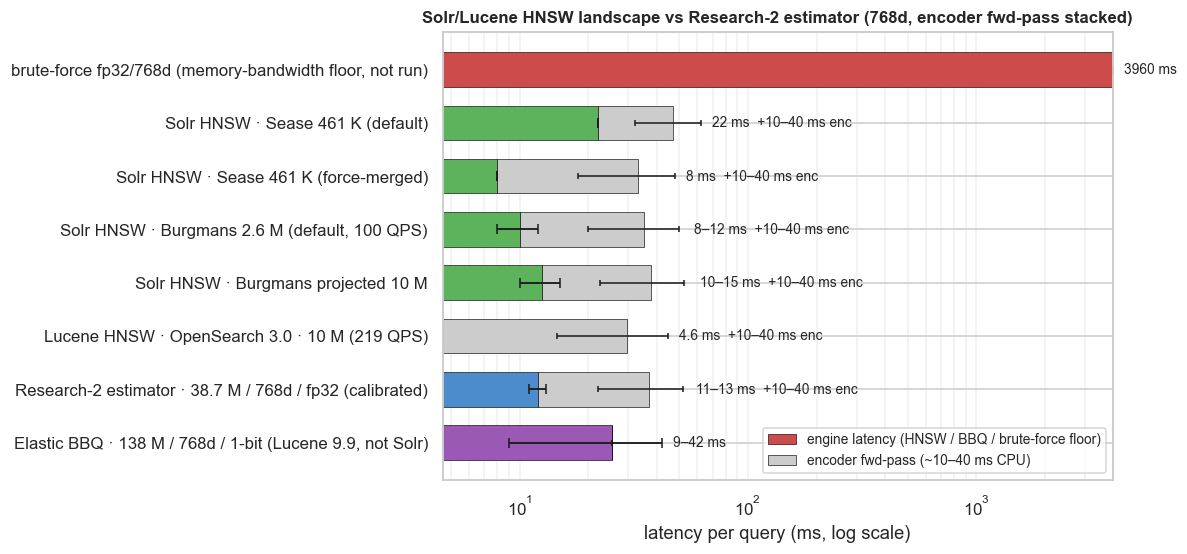

,system,corpus_M,lat_lo_ms,lat_hi_ms,enc_lo_ms,enc_hi_ms
0,"brute-force fp32/768d (memory-bandwidth floor,...",38.689459,3960.0,3960.0,0,0
1,Solr HNSW · Sease 461 K (default),0.461000,22.0,22.0,10,40
2,Solr HNSW · Sease 461 K (force-merged),0.461000,8.0,8.0,10,40
3,"Solr HNSW · Burgmans 2.6 M (default, 100 QPS)",2.600000,8.0,12.0,10,40
4,Solr HNSW · Burgmans projected 10 M,10.000000,10.0,15.0,10,40
5,Lucene HNSW · OpenSearch 3.0 · 10 M (219 QPS),10.000000,4.6,4.6,10,40
6,Research-2 estimator · 38.7 M / 768d / fp32 (c...,38.689459,11.0,13.0,10,40
7,Elastic BBQ · 138 M / 768d / 1-bit (Lucene 9.9...,138.000000,9.0,42.0,0,0


In [8]:
# Place our brute-force prediction (canonical cohort, fp32/768d) against published HNSW latencies,
# with the query-encoder forward pass stacked on top of every Solr/Lucene HNSW bar (~10-40 ms CPU,
# sentence-transformer 768d). The Elastic BBQ point is server-side and includes only its own engine
# latency (no encoder segment) — included as a forward-look reference for if/when BBQ lands in Solr.
# Brute-force is a never-actually-run memory-bandwidth floor, so it carries no encoder segment.
# Keep N from the Research-2 cell so this matches the canonical cohort.
points = pd.DataFrame([
    {'system': 'brute-force fp32/768d (memory-bandwidth floor, not run)', 'corpus_M': N / 1e6, 'lat_lo_ms': 3960, 'lat_hi_ms': 3960, 'enc_lo_ms': 0,  'enc_hi_ms': 0},
    {'system': 'Solr HNSW · Sease 461 K (default)',                       'corpus_M': 0.461,   'lat_lo_ms': 22,   'lat_hi_ms': 22,   'enc_lo_ms': 10, 'enc_hi_ms': 40},
    {'system': 'Solr HNSW · Sease 461 K (force-merged)',                  'corpus_M': 0.461,   'lat_lo_ms': 8,    'lat_hi_ms': 8,    'enc_lo_ms': 10, 'enc_hi_ms': 40},
    {'system': 'Solr HNSW · Burgmans 2.6 M (default, 100 QPS)',           'corpus_M': 2.6,     'lat_lo_ms': 8,    'lat_hi_ms': 12,   'enc_lo_ms': 10, 'enc_hi_ms': 40},
    {'system': 'Solr HNSW · Burgmans projected 10 M',                     'corpus_M': 10.0,    'lat_lo_ms': 10,   'lat_hi_ms': 15,   'enc_lo_ms': 10, 'enc_hi_ms': 40},
    {'system': 'Lucene HNSW · OpenSearch 3.0 · 10 M (219 QPS)',           'corpus_M': 10.0,    'lat_lo_ms': 4.6,  'lat_hi_ms': 4.6,  'enc_lo_ms': 10, 'enc_hi_ms': 40},
    {'system': 'Research-2 estimator · 38.7 M / 768d / fp32 (calibrated)','corpus_M': N / 1e6, 'lat_lo_ms': 11,   'lat_hi_ms': 13,   'enc_lo_ms': 10, 'enc_hi_ms': 40},
    {'system': 'Elastic BBQ · 138 M / 768d / 1-bit (Lucene 9.9, not Solr)','corpus_M': 138.0,  'lat_lo_ms': 9,    'lat_hi_ms': 42,   'enc_lo_ms': 0,  'enc_hi_ms': 0},
])
points['lat_mid_ms'] = (points['lat_lo_ms'] + points['lat_hi_ms']) / 2
points['enc_mid_ms'] = (points['enc_lo_ms'] + points['enc_hi_ms']) / 2
points['err_lo']     = points['lat_mid_ms'] - points['lat_lo_ms']
points['err_hi']     = points['lat_hi_ms'] - points['lat_mid_ms']
points['enc_err_lo'] = points['enc_mid_ms'] - points['enc_lo_ms']
points['enc_err_hi'] = points['enc_hi_ms'] - points['enc_mid_ms']

fig, ax = plt.subplots(figsize=(11.0, 5.2))
y = np.arange(len(points))
def _color(system: str) -> str:
    if 'brute-force' in system:    return '#cc4c4c'
    if 'estimator'   in system:    return '#4c8ccc'
    if 'BBQ'         in system:    return '#9b59b6'
    return '#5cb35c'
colors = [_color(s) for s in points['system']]

# HNSW (or brute-force / BBQ) segment
ax.barh(y, points['lat_mid_ms'],
        xerr=[points['err_lo'], points['err_hi']],
        color=colors, edgecolor='black', linewidth=0.4, height=0.65,
        error_kw={'elinewidth': 1.2, 'capsize': 3},
        label='engine latency (HNSW / BBQ / brute-force floor)')
# Encoder forward-pass segment, stacked to the right of the HNSW bar (zero-width if enc=0)
ax.barh(y, points['enc_mid_ms'], left=points['lat_mid_ms'],
        xerr=[points['enc_err_lo'], points['enc_err_hi']],
        color='#cccccc', edgecolor='black', linewidth=0.4, height=0.65,
        error_kw={'elinewidth': 1.0, 'capsize': 2},
        label='encoder fwd-pass (~10–40 ms CPU)')
for yi, row in zip(y, points.itertuples()):
    if row.lat_lo_ms == row.lat_hi_ms:
        label = f'{row.lat_lo_ms:g} ms'
    else:
        label = f'{row.lat_lo_ms:g}–{row.lat_hi_ms:g} ms'
    if row.enc_mid_ms > 0:
        label += f'  +{row.enc_lo_ms:g}–{row.enc_hi_ms:g} ms enc'
    ax.text((row.lat_hi_ms + row.enc_hi_ms) * 1.12, yi, label, va='center', fontsize=9)
ax.set_xscale('log')
ax.set_yticks(y); ax.set_yticklabels(points['system'])
ax.set_xlabel('latency per query (ms, log scale)')
ax.set_title('Solr/Lucene HNSW landscape vs Research-2 estimator (768d, encoder fwd-pass stacked)')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', which='both', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'hnsw_comparison.png', bbox_inches='tight')
plt.show()

points[['system', 'corpus_M', 'lat_lo_ms', 'lat_hi_ms', 'enc_lo_ms', 'enc_hi_ms']]

## Takeaway

*Cohort numbers exclude rows with NA-OCRQA, OCRQA <0.5, or length <200 — see drop ladder in Research 1.*

At the canonical cohort (`ocrqa ≥ 0.6, len ≥ 400`, **38.7 M** article+ad items), Solr 9.x with default Lucene HNSW (`M = 16`):

| dim × prec        | index size (formula) | HNSW p50 (calibrated) | end-to-end p50 (+enc 10–40 ms) |
|-------------------|---------------------:|----------------------:|-------------------------------:|
| 768d × fp32       | ~136 GB              | ~12 ms                | ~22–52 ms                      |
| 768d × int8       | ~38 GB               | ~3 ms                 | ~13–43 ms                      |
| 512d × fp32       | ~92 GB               | ~8 ms                 | ~18–48 ms                      |
| 512d × int8       | ~27 GB               | ~2 ms                 | ~12–42 ms                      |
| 256d × fp32       | ~49 GB               | ~4 ms                 | ~14–44 ms                      |
| 256d × int8       | ~16 GB               | ~1 ms                 | ~11–41 ms                      |
| 128d × fp32       | ~27 GB               | ~2 ms                 | ~12–42 ms                      |
| 128d × int8       | ~11 GB               | ~0.5 ms               | ~10.5–40.5 ms                  |

(See Research-2 cell for the live numbers; values above are the formula evaluated at `N = 38.7 M`. Force-merge can shave another 2–10× off HNSW p50; not modelled here.)

**What this means in practice:**

- The **fp32/768d default** fits in a single high-RAM host (~136 GB index ⇒ 192 GB host comfortably). **Total user-perceived latency ~22–52 ms** at p50 — dominated by the encoder forward pass, not Solr.
- Dropping to **int8/768d** (Solr `vectorEncoding=BYTE`) cuts the index to ~38 GB and HNSW to ~3 ms with negligible recall cost on most encoders (model-dependent; not yet measured for `gte-multilingual-base`).
- Dropping to **256d** (Matryoshka native truncation, **free**) cuts another 3× on top — `256d × int8` lands at ~16 GB, which fits in DRAM on a commodity 32 GB host. Recall impact at 256d / 128d is **the** open question; the model card says it stays competitive ≥ 512d on MTEB English but Impresso multilingual + OCR-noisy text needs its own measurement.
- **End-to-end is encoder-bound** at every operating point above ~256d × fp32. If query-time matters more than index size, the lever is GPU-warmed encoder caching, not vector quantization.

**Levers, in order of impact-per-effort:**

1. **256d Matryoshka truncation** — free at training time, 3× storage + latency cut. Risk: Impresso-specific recall regression. Validate on a held-out eval set before committing.
2. **int8 (BYTE) encoding** — 4× storage, ~2× latency speedup at higher k under load (Lucene benchmarks). Requires fp32 → int8 calibration step at index time.
3. **Tighten cohort**: `ocrqa ≥ 0.7, len ≥ 600` → 32 M (−17 %), `ocrqa ≥ 0.5, len ≥ 200` → 48 M (+25 %). All Research-2 numbers scale linearly with N (storage) and `~log(N)` (HNSW).
4. **Force-merge after bulk-load** — up to 10× HNSW speedup (Sease 461 K: 22 → 8 ms). Costs 30–90 min one-shot; not free per-commit.
5. **Avoid narrow post-filters** (1–5 % selectivity) — they break HNSW. Pre-filter the corpus before kNN if you need them.
6. **BBQ watch**: if `BinaryQuantizedDenseVectorField` ships in Solr 10.x, expect another ~8× memory cut at the cost of 3× oversampling — Elastic 138 M precedent at 9–42 ms. Re-run the estimator then.

> **Why fp16 / bf16 are still absent**: Solr `vectorEncoding` accepts only `FLOAT32` or `BYTE`. Half-floats are a memory-only intermediate and cannot be ingested. If a future Solr version exposes them, they'd land between fp32 and int8 in this table at ~75 GB.